In [ ]:
pip install matplotlib

In [ ]:
pip install seaborn

## Import Required Libraries

The following libraries are used for data analysis and visualization:

- **pandas** – Data manipulation and DataFrame operations  
- **numpy** – Numerical calculations and array processing  
- **matplotlib** – Basic data visualization  
- **seaborn** – Statistical visualization built on matplotlib  
- **os** – Operating system interaction (file paths, folders)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Set Processed Data Folder Path

In [2]:
processed_folder_path = "data/processed"

## Load Initial Processed Data

Load the required processed datasets for analysis:

- **seats.csv** → Contains constituency/seat information.
- **pooling_centres.csv** → Contains polling center details.
- **candidates_data.csv** → Contains candidate information.

All files are stored in the `data/processed` directory and loaded using **pandas**.

In [3]:
file_to_read = os.path.join(processed_folder_path, "seats.csv")
seats_df = pd.read_csv(file_to_read, encoding="utf-8-sig")

file_to_read = os.path.join(processed_folder_path, "pooling_centres.csv")
pooling_centeres_df = pd.read_csv(file_to_read, encoding="utf-8-sig")


file_to_read = os.path.join(processed_folder_path, "candidates_data.csv")
candidates_df = pd.read_csv(file_to_read, encoding="utf-8-sig")



In [4]:
display(candidates_df)

,seat_id,center_no,candidate_name,symbol,candidate_vote
0,1,163,আব্দুল্লাহ আল ফারুখ,দাঁড়িপাল্লা,303
1,1,163,মোঃ ছরওয়ার আলম কুতুবী,হাতপাখা,23
2,1,163,সালাহউদ্দিন আহমদ,ধানের শীষ,1414
3,1,145,আব্দুল্লাহ আল ফারুখ,দাঁড়িপাল্লা,670
4,1,145,মোঃ ছরওয়ার আলম কুতুবী,হাতপাখা,10
...,...,...,...,...,...
289903,297,150,মোঃ মিজানুর রহমান চৌধুরী,ঘোড়া,0
289904,297,150,মোঃ মুজিবুর রহমান,মই,0
289905,297,150,মোঃ রাশেদুল ইসলাম খোকন,ছড়ি,0
289906,297,150,শাহ মোঃ আল আমিন,হারিকেন,1


In [5]:
display(pooling_centeres_df)

,seat_id,center_no,center_name,legal_vote,cancel_vote,Absent_vote,total_vote,cast_vote
0,1,163,"কোরআনিয়া দারুল উলুম মাদ্রাসাগ্রাম:পেকুয়রচর, ডা...",1740,34,1368,3142,1774
1,1,145,ফাঁসিয়াখালী সরকারী প্রাথমিক বিদ্যালয়গ্রাম: সবজ...,1703,19,677,2399,1722
2,1,164,করিয়ারদিয়া সরকারী প্রাথমিক বিদ্যালয়গ্রামঃ করিয়...,919,19,494,1432,938
3,1,148,"টৈটং হাই স্কুলগ্রাম:+ডাক+ইউনিয়ন: টৈটং, উপজেলা:...",2032,46,823,2901,2078
4,1,32,ঢেমুশিয়া জিন্নত আলী চৌং উচ্চ বিদ্যালয়জমিদার পা...,2078,38,1156,3272,2116
...,...,...,...,...,...,...,...,...
42379,297,146,বড়ধলিয়া জগদীশপুর প্রগতি সরকারী প্রাথমিক বিদ্যা...,2049,51,1570,3670,2100
42380,297,147,"বানেশ্বর সরকারী প্রাথমিক বিদ্যালয়, সাং- বানেশ্...",948,4,891,1843,952
42381,297,148,বানেশ্বর উচ্চ বিদ্যালয় সাং- বানেশ্বরগ্রামঃ বান...,1109,7,827,1943,1116
42382,297,149,"ধনকুড়া সরকারী প্রাথমিক বিদ্যালয়, সাং- ধনকুড়াগ্...",1822,57,1422,3301,1879


## Calculate Voting Statistics

This section calculates the following totals from the polling centre dataset:

- **Total Voters** → Sum of registered voters  
- **Total Cast Votes** → Total votes received   
- **Total Legal/Valid Votes** → Total approved votes 
- **Total Cancelled Votes** → Invalid or rejected votes  

These metrics help analyze overall election turnout and vote validity.

In [6]:
total_voters = pooling_centeres_df['total_vote'].sum()  # Total Voters
total_cast_vote = pooling_centeres_df['cast_vote'].sum()   # Total votes received (প্রাপ্ত ভোট)
total_valid_vote = pooling_centeres_df['legal_vote'].sum()   # # Total legal / valid votes (মোট বৈধ ভোট)
total_cancelled_vote = pooling_centeres_df['cancel_vote'].sum()   #  # Total illegal / cancelled votes

In [8]:
print("Election Summary (ভোটের সারসংক্ষেপ)")
print("----------------------------------")
print(f"Total Voters (মোট ভোটার)           : {total_voters}")
print(f"Votes Cast (প্রদত্ত ভোট)           : {total_cast_vote}")
print(f"Valid Votes (মোট বৈধ ভোট)          : {total_valid_vote}")
print(f"Cancelled Votes (মোট বাতিল ভোট)    : {total_cancelled_vote}")


Election Summary (ভোটের সারসংক্ষেপ)
----------------------------------
Total Voters (মোট ভোটার)           : 124837534
Votes Cast (প্রদত্ত ভোট)           : 75128700
Valid Votes (মোট বৈধ ভোট)          : 73510765
Cancelled Votes (মোট বাতিল ভোট)    : 1617935


## Calculate Voting Percentages

This section calculates important election KPIs:

- **Voter Turnout %** → Percentage of cast votes from total registered voters  
- **Valid Vote %** → Percentage of legal votes from total cast votes  
- **Illegal Vote %** → Percentage of cancelled/invalid votes from total cast votes  

These metrics help evaluate election participation and vote quality.

In [9]:

# Calculate percentages
voter_turnout_pct = (total_cast_vote / total_voters) * 100 if total_voters else 0
valid_vote_pct = (total_valid_vote / total_cast_vote) * 100 if total_cast_vote else 0
illegal_vote_pct = (total_cancelled_vote / total_cast_vote) * 100 if total_cast_vote else 0


In [10]:
# Print results (rounded to 2 decimals)
print(f"Voter Turnout: {voter_turnout_pct:.2f}%")
print(f"Valid Vote Percentage: {valid_vote_pct:.2f}%")
print(f"Illegal / Cancelled Vote Percentage: {illegal_vote_pct:.2f}%")

Voter Turnout: 60.18%
Valid Vote Percentage: 97.85%
Illegal / Cancelled Vote Percentage: 2.15%


In [11]:
display(candidates_df)

,seat_id,center_no,candidate_name,symbol,candidate_vote
0,1,163,আব্দুল্লাহ আল ফারুখ,দাঁড়িপাল্লা,303
1,1,163,মোঃ ছরওয়ার আলম কুতুবী,হাতপাখা,23
2,1,163,সালাহউদ্দিন আহমদ,ধানের শীষ,1414
3,1,145,আব্দুল্লাহ আল ফারুখ,দাঁড়িপাল্লা,670
4,1,145,মোঃ ছরওয়ার আলম কুতুবী,হাতপাখা,10
...,...,...,...,...,...
289903,297,150,মোঃ মিজানুর রহমান চৌধুরী,ঘোড়া,0
289904,297,150,মোঃ মুজিবুর রহমান,মই,0
289905,297,150,মোঃ রাশেদুল ইসলাম খোকন,ছড়ি,0
289906,297,150,শাহ মোঃ আল আমিন,হারিকেন,1


## Symbol-wise Vote Distribution

This section calculates the total votes received by each party symbol.

Steps:
- Group data by **symbol**
- Calculate total votes per symbol
- Sort symbols in descending order of votes
- Compute percentage share of total cast votes

This helps analyze party-wise performance in the election.

In [12]:
df_symbol_dist = candidates_df.groupby(['symbol']).agg(
    total_votes=('candidate_vote', 'sum')
).reset_index().sort_values(by='total_votes', ascending=False)
df_symbol_dist['percentage'] = (df_symbol_dist['total_votes'] / total_cast_vote) * 100
df_symbol_dist['total_cast_vote'] =  total_cast_vote 
df_symbol_dist.reset_index(drop=True)


display(df_symbol_dist.head(10))

,symbol,total_votes,percentage,total_cast_vote
41,ধানের শীষ,36865688,49.070046,75128700
38,দাঁড়িপাল্লা,23186330,30.862147,75128700
64,শাপলা কলি,2233955,2.973504,75128700
73,হাতপাখা,1997447,2.658700,75128700
61,রিক্সা,1531148,2.038033,75128700
43,ফুটবল,1009522,1.343724,75128700
23,ঘোড়া,920653,1.225434,75128700
63,লাঙ্গল,660942,0.879746,75128700
39,দেওয়াল ঘড়ি,555167,0.738955,75128700
10,কলস,455840,0.606745,75128700


## Seat-wise Winner and Runner-up Analysis

This section determines:

- Total votes per **seat and symbol**
- Sorts candidates within each seat by vote count
- Identifies:
  - 🥇 **Winner** (1st position)
  - 🥈 **Runner-up** (2nd position)

This helps analyze constituency-level election results.

In [13]:

df_grouped_symbol_vote= candidates_df.groupby(['seat_id','symbol'])[['candidate_vote']].sum().reset_index()
df_grouped_symbol_vote_sorted= df_grouped_symbol_vote.sort_values(by=['seat_id', 'candidate_vote'],ascending=[True, False])

df_result_winner = df_grouped_symbol_vote_sorted.groupby(['seat_id']).head(1).reset_index(drop=True) # First Position Position
df_result_runnerup = df_grouped_symbol_vote_sorted.groupby(['seat_id']).nth(1).reset_index(drop=True) # Second Position

display(df_result_winner)
display(df_result_runnerup)

,seat_id,symbol,candidate_vote
0,1,ধানের শীষ,219758
1,2,ধানের শীষ,124660
2,3,ধানের শীষ,180507
3,4,ধানের শীষ,123021
4,5,ধানের শীষ,122945
...,...,...,...
292,293,ধানের শীষ,150810
293,294,ধানের শীষ,111073
294,295,ধানের শীষ,125971
295,296,ধানের শীষ,141521


,seat_id,symbol,candidate_vote
0,1,দাঁড়িপাল্লা,125311
1,2,দাঁড়িপাল্লা,89817
2,3,দাঁড়িপাল্লা,156019
3,4,দাঁড়িপাল্লা,120096
4,5,রিক্সা,99490
...,...,...,...
292,293,দাঁড়িপাল্লা,99672
293,294,রিক্সা,55245
294,295,দেওয়াল ঘড়ি,64851
295,296,দাঁড়িপাল্লা,44581


### Seat-wise Winner Identification

This section identifies the **winning candidate for each constituency (seat)** based on the highest number of votes.

---

#### 1. Aggregate Candidate Votes per Seat
Group the dataset by **seat_id, candidate_name, and symbol**, and calculate the **total votes** received by each candidate in that seat.

```python
df_grouped_symbol_vote2 = candidates_df.groupby(
    ['seat_id','candidate_name','symbol']
)[['candidate_vote']].sum().reset_index()

In [53]:
df_grouped_symbol_vote2= candidates_df.groupby(['seat_id','candidate_name','symbol'])[['candidate_vote']].sum().reset_index()
df_grouped_symbol_vote_sorted2= df_grouped_symbol_vote2.sort_values(by=['seat_id', 'candidate_vote'],ascending=[True, False])

df_result_winner2 = df_grouped_symbol_vote_sorted2.groupby(['seat_id']).head(1).reset_index(drop=True) # First Position Position

df_joined_symbol_percent_winner2 = pd.merge(
    seats_df,
    df_result_winner2,
    on=["seat_id"],
    how="left"
)

df_joined_symbol_percent_winner2.to_csv("output.csv" , index=False, encoding="utf-8-sig")

### Party-wise Seat Position Analysis

This section calculates the **number of seats won by each symbol (party)** and the **number of runner-up positions**.

---

#### 1. Calculate Total Seats Won by Each Symbol

```python
winner_count = df_result_winner.groupby("symbol").size().reset_index(name="seat_won")

In [14]:
winner_count = df_result_winner.groupby("symbol").size().reset_index(name="seat_won")
runner_up_count = df_result_runnerup.groupby("symbol").size().reset_index(name="2nd_Position")
display(runner_up_count)

,symbol,2nd_Position
0,ঈগল,2
1,কলস,3
2,কাপ-পিরিচ,1
3,কোদাল,1
4,খেজুর গাছ,4
5,ঘোড়া,8
6,ছাতা,4
7,ট্রাক,2
8,তালা,2
9,দাঁড়িপাল্লা,142


### Party-wise Seat Performance Summary

This section combines **symbol distribution data**, **seat wins**, and **runner-up counts** to create a **party-wise performance summary**.

---

#### 1. Merge Symbol Distribution with Seat Wins

```python
df_joined_symbol_percent_winner = pd.merge(
    df_symbol_dist,
    winner_count,
    on=["symbol"],
    how="left"
)


In [15]:
df_joined_symbol_percent_winner = pd.merge(
    df_symbol_dist,
    winner_count,
    on=["symbol"],
    how="left"
)

df_joined_2= pd.merge(
    df_joined_symbol_percent_winner,
    runner_up_count,
    on=["symbol"],
    how="left"
)
df_joined_2["seat_won"] = df_joined_2["seat_won"].fillna(0)
df_joined_2["2nd_Position"] = df_joined_2["2nd_Position"].fillna(0)

display(df_joined_2)

,symbol,total_votes,percentage,total_cast_vote,seat_won,2nd_Position
0,ধানের শীষ,36865688,49.070046,75128700,211.0,71.0
1,দাঁড়িপাল্লা,23186330,30.862147,75128700,67.0,142.0
2,শাপলা কলি,2233955,2.973504,75128700,6.0,16.0
3,হাতপাখা,1997447,2.658700,75128700,1.0,4.0
4,রিক্সা,1531148,2.038033,75128700,1.0,15.0
...,...,...,...,...,...,...
72,সোফা,206,0.000274,75128700,0.0,0.0
73,কবুতর,190,0.000253,75128700,0.0,0.0
74,সিড়ি,181,0.000241,75128700,0.0,0.0
75,দোয়াত কলম,166,0.000221,75128700,0.0,0.0


### Party Grouping and Final Summary

This step groups smaller parties into an **"Others" category** and creates a **final party-wise performance summary**.

---

#### 1. Create Symbol Groups

```python
df_joined_2["symbol_group"] = df_joined_2.apply(
    lambda x: x["symbol"] if x["seat_won"] > 1 else "Others",
    axis=1
)

In [16]:
df_joined_2["symbol_group"] = df_joined_2.apply(
    lambda x: x["symbol"] if x["seat_won"] > 1 else "Others",
    axis=1
)


df_final = df_joined_2.groupby("symbol_group").agg(
    total_votes=("total_votes", "sum"),
    percentage=("percentage", "sum"),
    seat_won=("seat_won", "sum"),
    second_position=("2nd_Position", "sum")
).reset_index()
 
df_final = df_final.sort_values("seat_won", ascending=False)

display(df_final)

,symbol_group,total_votes,percentage,seat_won,second_position
2,ধানের শীষ,36865688,49.070046,211.0,71.0
1,দাঁড়িপাল্লা,23186330,30.862147,67.0,142.0
0,Others,10783352,14.353173,11.0,65.0
3,শাপলা কলি,2233955,2.973504,6.0,16.0
4,হাঁস,441440,0.587578,2.0,3.0


### Seat-wise Voter Turnout Calculation

This step calculates the **voter turnout percentage for each constituency (seat)** using polling center data.

---

#### 1. Aggregate Votes by Seat

```python
df_seat_wise_summary = pooling_centeres_df.groupby(
    ['seat_id']
)[['total_vote','cast_vote']].sum().reset_index()

In [17]:

df_seat_wise_summary=pooling_centeres_df.groupby(['seat_id'])[['total_vote','cast_vote']].sum().reset_index()
df_seat_wise_summary['voter_turnout_pct'] = (
    df_seat_wise_summary['cast_vote'] /
    df_seat_wise_summary['total_vote']
) * 100
df_seat_wise_summary['voter_turnout_pct'] .fillna(0)
display(df_seat_wise_summary)




,seat_id,total_vote,cast_vote,voter_turnout_pct
0,1,530855,355537,66.974409
1,2,383639,229624,59.854186
2,3,535046,348939,65.216636
3,4,371822,252646,67.948104
4,5,548732,270777,49.345947
...,...,...,...,...
292,293,521897,260051,49.828031
293,294,462623,212186,45.865856
294,295,391917,199269,50.844694
295,296,416322,212269,50.986736


### Voter Turnout Percentage Range Classification

This step categorizes **voter turnout percentages into predefined ranges** to make analysis easier.

---

#### 1. Define Turnout Percentage Bins

```python
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 101]

In [18]:

bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 101]
labels = [
    '0–10%',
    '10–20%',
    '20–30%',
    '30–40%',
    '40–50%',
    '50–60%',
    '60–70%',
    '70–80%',
    '80–90%',
    '90–100%'
]

df_seat_wise_summary['turnout_pct_range'] = pd.cut(
    df_seat_wise_summary['voter_turnout_pct'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)


display(df_seat_wise_summary)


,seat_id,total_vote,cast_vote,voter_turnout_pct,turnout_pct_range
0,1,530855,355537,66.974409,60–70%
1,2,383639,229624,59.854186,50–60%
2,3,535046,348939,65.216636,60–70%
3,4,371822,252646,67.948104,60–70%
4,5,548732,270777,49.345947,40–50%
...,...,...,...,...,...
292,293,521897,260051,49.828031,40–50%
293,294,462623,212186,45.865856,40–50%
294,295,391917,199269,50.844694,50–60%
295,296,416322,212269,50.986736,50–60%


### Turnout Percentage Range Distribution

This step calculates the **number of constituencies (seats) within each voter turnout percentage range**.

---

#### 1. Count Seats in Each Turnout Range

```python
interval_counts2 = df_seat_wise_summary['turnout_pct_range'].value_counts().sort_index().reset_index()

In [19]:

interval_counts2 = df_seat_wise_summary['turnout_pct_range'].value_counts().sort_index().reset_index()

display(interval_counts2)

,turnout_pct_range,count
0,0–10%,0
1,10–20%,0
2,20–30%,0
3,30–40%,2
4,40–50%,40
5,50–60%,114
6,60–70%,82
7,70–80%,59
8,80–90%,0
9,90–100%,0


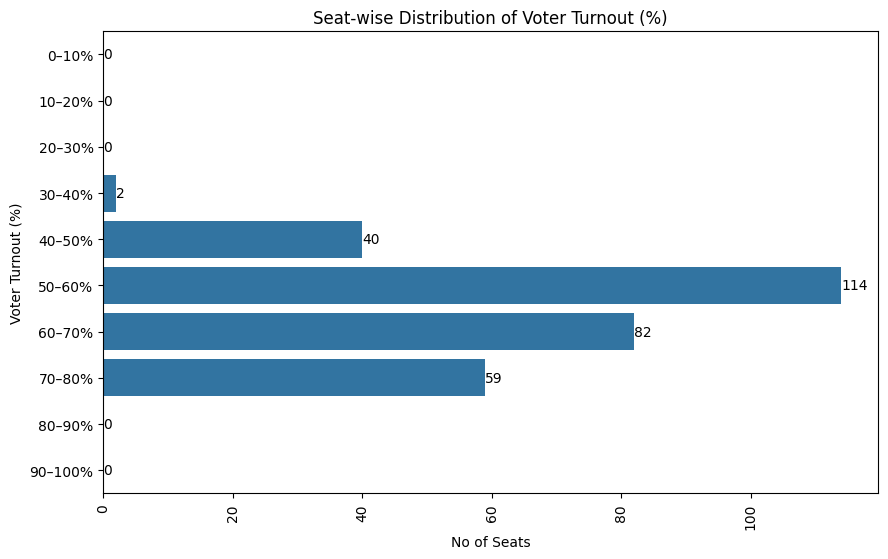

In [20]:

interval_counts2.columns = ['intervals', 'count']
# Plotting the intervals
plt.figure(figsize=(10, 6))

ax=sns.barplot(x='count', y='intervals', data=interval_counts2, orient='h')
plt.title('Seat-wise Distribution of Voter Turnout (%)')
plt.xlabel('No of Seats')
plt.ylabel('Voter Turnout (%)')
for index, value in enumerate(interval_counts2['count']):
    ax.text(value, index, str(value), color='black', va='center')
plt.xticks(rotation=90)

plt.show()

In [21]:
df_seat_joined_seat_summary = pd.merge(
    seats_df,
    df_seat_wise_summary,
    on=["seat_id"],
    how="left"
)

display(df_seat_joined_seat_summary)

,zilla_name,seat_id,seat_name,total_vote,cast_vote,voter_turnout_pct,turnout_pct_range
0,কক্সবাজার,1,কক্সবাজার-১,530855,355537,66.974409,60–70%
1,কক্সবাজার,2,কক্সবাজার-২,383639,229624,59.854186,50–60%
2,কক্সবাজার,3,কক্সবাজার-৩,535046,348939,65.216636,60–70%
3,কক্সবাজার,4,কক্সবাজার-৪,371822,252646,67.948104,60–70%
4,কিশোরগঞ্জ,5,কিশোরগঞ্জ-১,548732,270777,49.345947,40–50%
...,...,...,...,...,...,...,...
292,সুনামগঞ্জ,293,সুনামগঞ্জ-৫,521897,260051,49.828031,40–50%
293,হবিগঞ্জ,294,হবিগঞ্জ-১,462623,212186,45.865856,40–50%
294,হবিগঞ্জ,295,হবিগঞ্জ-২,391917,199269,50.844694,50–60%
295,হবিগঞ্জ,296,হবিগঞ্জ-৩,416322,212269,50.986736,50–60%


### Top 5 Constituencies by Voter Turnout

This section identifies the **five constituencies with the highest voter turnout percentage**.

---

#### 1. Sort Seats by Turnout (Descending)

```python
top5 = df_seat_joined_seat_summary.sort_values(
    by="voter_turnout_pct",
    ascending=False
).head(5)

In [22]:
top5 = df_seat_joined_seat_summary.sort_values(by="voter_turnout_pct", ascending=False).head(5)

top5 = top5[["zilla_name", "seat_name", "voter_turnout_pct"]]

display(top5)

,zilla_name,seat_name,voter_turnout_pct
72,চুয়াডাঙ্গা,চুয়াডাঙ্গা-২,78.217088
244,যশোর,যশোর-৬,77.883872
84,ঝিনাইদহ,ঝিনাইদহ-৩,77.861214
123,নওগাঁ,নওগাঁ-১,77.479184
160,পঞ্চগড়,পঞ্চগড়-১,77.387195


### Bottom 5 Constituencies by Voter Turnout

This section identifies the **five constituencies with the lowest voter turnout percentage**.

---

#### 1. Sort Seats by Turnout (Ascending)

```python
bottom5 = df_seat_joined_seat_summary.sort_values(
    by="voter_turnout_pct",
    ascending=True
).head(5)

In [23]:
bottom5 = df_seat_joined_seat_summary.sort_values(by="voter_turnout_pct", ascending=True).head(5)

bottom5 = bottom5[["zilla_name", "seat_name", "voter_turnout_pct"]]

display(bottom5)

,zilla_name,seat_name,voter_turnout_pct
100,ঢাকা,ঢাকা-১২,37.090211
47,গোপালগঞ্জ,গোপালগঞ্জ-২,39.594426
51,চট্টগ্রাম,চট্রগ্রাম-১১,41.364216
62,চট্টগ্রাম,চট্রগ্রাম-৯,41.810755
115,ঢাকা,ঢাকা-৮,42.956748


# Pooling Centwer wise Analysis
----

### Polling Center-wise Voter Turnout Analysis

This section calculates the **voter turnout percentage for each polling center** within every constituency.

---

#### 1. Aggregate Votes by Seat and Polling Center

```python
df_polling_center_summary = pooling_centeres_df.groupby(
    ['seat_id','center_no','center_name']
)[['total_vote','cast_vote']].sum().reset_index()

In [24]:
df_polling_center_summary=pooling_centeres_df.groupby(['seat_id','center_no','center_name'])[['total_vote','cast_vote']].sum().reset_index()
df_polling_center_summary['voter_turnout_pct'] = (
    df_polling_center_summary['cast_vote'] /
    df_polling_center_summary['total_vote']
) * 100
df_polling_center_summary['voter_turnout_pct'] .fillna(0)
display(df_polling_center_summary)


,seat_id,center_no,center_name,total_vote,cast_vote,voter_turnout_pct
0,1,1,নিদানতরানী সরকারি প্রাথমিক বিদ্যালয়ঢেমুশিয়া পা...,3068,1892,61.668840
1,1,2,কুতুব নগর সরকারি প্রাথমিক বিদ্যালয়কুতুবনগর পাড়...,3044,1894,62.220762
2,1,3,"বদরখালী কলোনিজেশন হাইস্কুলবদরখালী ,চকরিয়া,কক্স...",2526,1639,64.885194
3,1,4,বদরখালী এম.এস ফাজিল (ডিগ্রী) মাদরাসাবদরখালী,2796,1780,63.662375
4,1,5,জব্বর নগর সরকারী প্রাথমিক বিদ্যালয়জব্বরনগর পাড়...,2797,1903,68.037183
...,...,...,...,...,...,...
42379,297,179,"কাটিয়ারা সরকারী প্রাথমিক বিদ্যালয়, সাং- কাটিয়া...",2310,1352,58.528139
42380,297,180,"মাধবপুর পাইলট উচ্চ বিদ্যালয়, সাং- মাধবপুরগ্রাম...",4335,2391,55.155709
42381,297,181,"গুমুটিয়া সরকারী প্রাথমিক বিদ্যালয়, সাং- গুমুটি...",1651,1068,64.688068
42382,297,182,"সৈয়দ সঈদ উদ্দিন ডিগ্রী কলেজ, সাং- মাধবপুর পশ্চ...",2795,1900,67.978533


### Polling Center Turnout Percentage Range Classification

This section categorizes **polling center voter turnout percentages** into defined ranges for better analysis and visualization.

---

#### 1. Define Turnout Percentage Bins

```python
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 101]

In [25]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 101]
labels = [
    '0–10%',
    '10–20%',
    '20–30%',
    '30–40%',
    '40–50%',
    '50–60%',
    '60–70%',
    '70–80%',
    '80–90%',
    '90–100%'
]

df_polling_center_summary['turnout_pct_range'] = pd.cut(
    df_polling_center_summary['voter_turnout_pct'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)


display(df_polling_center_summary)


,seat_id,center_no,center_name,total_vote,cast_vote,voter_turnout_pct,turnout_pct_range
0,1,1,নিদানতরানী সরকারি প্রাথমিক বিদ্যালয়ঢেমুশিয়া পা...,3068,1892,61.668840,60–70%
1,1,2,কুতুব নগর সরকারি প্রাথমিক বিদ্যালয়কুতুবনগর পাড়...,3044,1894,62.220762,60–70%
2,1,3,"বদরখালী কলোনিজেশন হাইস্কুলবদরখালী ,চকরিয়া,কক্স...",2526,1639,64.885194,60–70%
3,1,4,বদরখালী এম.এস ফাজিল (ডিগ্রী) মাদরাসাবদরখালী,2796,1780,63.662375,60–70%
4,1,5,জব্বর নগর সরকারী প্রাথমিক বিদ্যালয়জব্বরনগর পাড়...,2797,1903,68.037183,60–70%
...,...,...,...,...,...,...,...
42379,297,179,"কাটিয়ারা সরকারী প্রাথমিক বিদ্যালয়, সাং- কাটিয়া...",2310,1352,58.528139,50–60%
42380,297,180,"মাধবপুর পাইলট উচ্চ বিদ্যালয়, সাং- মাধবপুরগ্রাম...",4335,2391,55.155709,50–60%
42381,297,181,"গুমুটিয়া সরকারী প্রাথমিক বিদ্যালয়, সাং- গুমুটি...",1651,1068,64.688068,60–70%
42382,297,182,"সৈয়দ সঈদ উদ্দিন ডিগ্রী কলেজ, সাং- মাধবপুর পশ্চ...",2795,1900,67.978533,60–70%


### Polling Center Turnout Range Distribution

This section calculates how many **polling centers fall into each voter turnout percentage range**.

---

#### 1. Count Polling Centers in Each Turnout Range

```python
interval_counts3 = df_polling_center_summary['turnout_pct_range'] \
    .value_counts() \
    .sort_index() \
    .reset_index()

In [26]:
interval_counts3 = df_polling_center_summary['turnout_pct_range'].value_counts().sort_index().reset_index()

display(interval_counts3)

,turnout_pct_range,count
0,0–10%,11
1,10–20%,28
2,20–30%,178
3,30–40%,1597
4,40–50%,5636
5,50–60%,13232
6,60–70%,12201
7,70–80%,8431
8,80–90%,1062
9,90–100%,8


### Polling Center-wise Voter Turnout Distribution (Visualization)

This section visualizes the **distribution of polling centers across voter turnout percentage ranges** using a horizontal bar chart.

---

#### 1. Rename Columns for Clarity

```python
interval_counts3.columns = ['intervals', 'count']

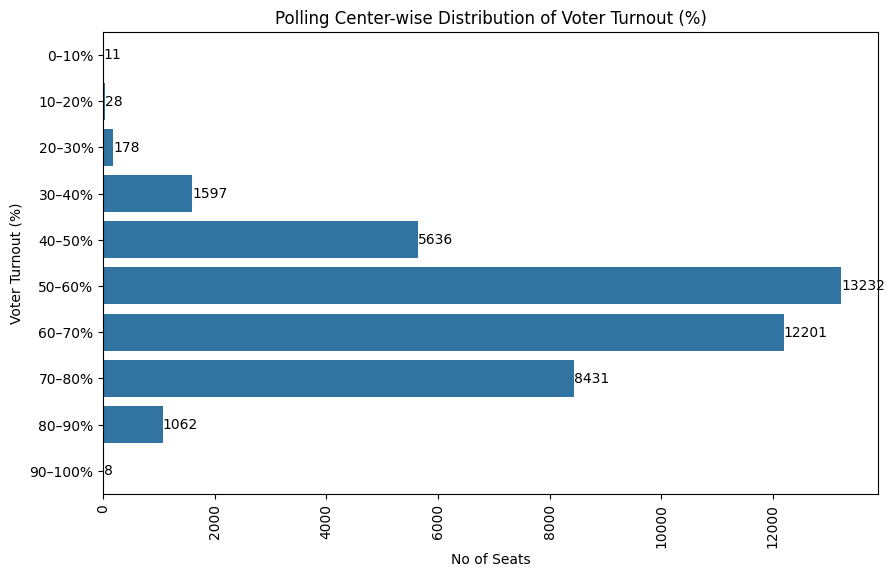

In [27]:
interval_counts3.columns = ['intervals', 'count']
# Plotting the intervals
plt.figure(figsize=(10, 6))

ax=sns.barplot(x='count', y='intervals', data=interval_counts3, orient='h')
plt.title('Polling Center-wise Distribution of Voter Turnout (%)')
plt.xlabel('No of Seats')
plt.ylabel('Voter Turnout (%)')
for index, value in enumerate(interval_counts3['count']):
    ax.text(value, index, str(value), color='black', va='center')
plt.xticks(rotation=90)

plt.show()

In [28]:
df_seat_joined_polling_centres_summary = pd.merge(
    seats_df,
    df_polling_center_summary,
    on=["seat_id"],
    how="left"
)

display(df_seat_joined_polling_centres_summary)

,zilla_name,seat_id,seat_name,center_no,center_name,total_vote,cast_vote,voter_turnout_pct,turnout_pct_range
0,কক্সবাজার,1,কক্সবাজার-১,1,নিদানতরানী সরকারি প্রাথমিক বিদ্যালয়ঢেমুশিয়া পা...,3068,1892,61.668840,60–70%
1,কক্সবাজার,1,কক্সবাজার-১,2,কুতুব নগর সরকারি প্রাথমিক বিদ্যালয়কুতুবনগর পাড়...,3044,1894,62.220762,60–70%
2,কক্সবাজার,1,কক্সবাজার-১,3,"বদরখালী কলোনিজেশন হাইস্কুলবদরখালী ,চকরিয়া,কক্স...",2526,1639,64.885194,60–70%
3,কক্সবাজার,1,কক্সবাজার-১,4,বদরখালী এম.এস ফাজিল (ডিগ্রী) মাদরাসাবদরখালী,2796,1780,63.662375,60–70%
4,কক্সবাজার,1,কক্সবাজার-১,5,জব্বর নগর সরকারী প্রাথমিক বিদ্যালয়জব্বরনগর পাড়...,2797,1903,68.037183,60–70%
...,...,...,...,...,...,...,...,...,...
42379,হবিগঞ্জ,297,হবিগঞ্জ-৪,179,"কাটিয়ারা সরকারী প্রাথমিক বিদ্যালয়, সাং- কাটিয়া...",2310,1352,58.528139,50–60%
42380,হবিগঞ্জ,297,হবিগঞ্জ-৪,180,"মাধবপুর পাইলট উচ্চ বিদ্যালয়, সাং- মাধবপুরগ্রাম...",4335,2391,55.155709,50–60%
42381,হবিগঞ্জ,297,হবিগঞ্জ-৪,181,"গুমুটিয়া সরকারী প্রাথমিক বিদ্যালয়, সাং- গুমুটি...",1651,1068,64.688068,60–70%
42382,হবিগঞ্জ,297,হবিগঞ্জ-৪,182,"সৈয়দ সঈদ উদ্দিন ডিগ্রী কলেজ, সাং- মাধবপুর পশ্চ...",2795,1900,67.978533,60–70%


### Top Polling Centers by Voter Turnout

This section identifies the **polling centers with the highest voter turnout percentage**.

---

#### 1. Select Required Columns

```python
cols = ["seat_name", "center_name", "voter_turnout_pct"]

In [29]:
cols = ["seat_name", "center_name", "voter_turnout_pct"]

top_center_5 = (
    df_seat_joined_polling_centres_summary
      .nlargest(10, "voter_turnout_pct")[cols]
)
with pd.option_context(
    "display.max_columns", None,
    "display.max_colwidth", None,
    "display.width", None,
):
    display(top_center_5)
    


,seat_name,center_name,voter_turnout_pct
31915,মেহেরপুর-২,ভাটপাড়া সরকারী প্রাথমিক বিদ্যালয়ভাটপাড়া,100.000000
22894,পঞ্চগড়-১,"বাংলাচন্ডি সরকারী প্রাথমিক বিদ্যালয়বাংলাচন্ডী, মানিকডোবা, তেতুলিয়া, পঞ্চগড়।",94.292237
3167,কুষ্টিয়া-২,ছত্রগাছা মাধ্যমিক বিদ্যালয়ছত্রগাছা,91.987605
9967,চাঁপাইনবাবগঞ্জ-২,পিড়াশন সরকারি প্রাথমিক বিদ্যালয়পিড়াশন,90.893901
23246,পটুয়াখালী-১,"কাঠালতলী মাধ্যমিক বিদ্যালয়। কাঠালতলীডাকঘরঃ কাঠালতলী, উপজেলাঃ মির্জাগঞ্জ, জেলাঃ পটুয়াখালী",90.749543
23262,পটুয়াখালী-১,"৯৬ নং পূর্ব আমড়াগাছিয়া সরকারী প্রাথমিক বিদ্যালয়, আমড়াগাছিয়াগ্রামঃ দঃ আমড়াগাছিয়া, পোঃ সুবিদখালী, উপজেলাঃ মির্জাগঞ্জ, জেলাঃ পটুয়াখালী",90.568283
38712,সাতক্ষীরা-২,"মাহমুদপুর আমিনিয়া সিনিয়র আলিম মাদ্রাসা, গাংনিয়া।",90.524412
9773,চাঁপাইনবাবগঞ্জ-১,"সীমান্ত সরকারি প্রাথমিক বিদ্যালয়গ্রামঃ শিয়ালমারা, ডাকঘরঃ সোনামসজিদ, উপজেলাঃ শিবগঞ্জ, জেলাঃ চাঁপাইনবাবগঞ্জ",90.058102
17568,দিনাজপুর-৬,"৮৭. ঢেলুপাড়া সরকারি প্রাথমিক বিদ্যালয়, সাং-মনিরামপুর (পুরুষ ও মহিলা) মনিরামপুর, ডাক: বিরামপুর, বিরামপুর, দিনাজপুর।",88.599578
10490,চুয়াডাঙ্গা-২,"কুনিয়া সরকারি প্রাথমিক বিদ্যালয়গ্রাম- কুনিয়া, পোষ্ট- নাটুদহ, উপজেলা- দামুড়হুদা, জেলা- চুয়াডাঙ্গা।",88.306105


### Bottom Polling Centers by Voter Turnout

This section identifies the **polling centers with the lowest voter turnout percentage**.

---

#### 1. Select Required Columns

```python
cols = ["seat_name", "center_name", "voter_turnout_pct"]

In [30]:
cols = ["seat_name", "center_name", "voter_turnout_pct"]

bottom_center_5 = (
    df_seat_joined_polling_centres_summary
      .nsmallest(10, "voter_turnout_pct")[cols]
)
with pd.option_context(
    "display.max_columns", None,
    "display.max_colwidth", None,
    "display.width", None,
):
    display(bottom_center_5)
    




,seat_name,center_name,voter_turnout_pct
2611,কুমিল্লা-৬,ক্যান্টমেন্ট বোর্ড বালক উচ্চ বিদ্যালয়কুমিল্লা সেনানিবাস এলাকা,3.102190
12706,টাংগাইল-৩,ক্যান্টনমেন্ট বোর্ড উচ্চ বিদ‌্যালয়ক্যান্টনমেন্ট,4.848246
34319,যশোর-৩,"দাউদ পাবলিক স্কুলযশোর সেনানিবাস, যশোর।",5.588585
26846,বগুড়া-৭,"১৭২। জাহাঙ্গীরাবাদ ক্যান্ট বোর্ড হাইস্কুলবগুড়া ক্যান্টমেন্ট, জাহাঙ্গীরাবাদ, ফুলতলা, শাজাহানপুর, বগুড়া।",5.829228
26847,বগুড়া-৭,"১৭৩। বগুড়া ক্যান্টবোর্ড হাইস্কুলবগুড়া ক্যান্টনমেন্ট, মাঝিড়া, শাজাহানপর, বগুড়া।",5.995782
28618,বান্দারবান,"পাকনিয়ার পাড়া সরকারী প্রাথমিক বিদ্যালয়পাকনিয়ার পাড়া, ৫নং ওয়ার্ড, রেমাক্রী প্রাংশা ইউপি, রুমা, বান্দরবান",6.183115
34318,যশোর-৩,"ক্যান্টনমেন্ট কলেজযশোর ক্যান্টনমেন্ট, যশোর সদর, যশোর।",7.013815
33202,ময়মনসিংহ-৪,"ক্যান্টনমেন্ট পাবলিক স্কুল এন্ড কলেজক্যান্টনমেন্ট,সদর,ময়মনসিংহ",8.108108
2610,কুমিল্লা-৬,ক্যান্টনমেন্ট বোর্ড গার্লস হাই স্কুলকুমিল্লা সেনানিবাস এলাকা,8.276900
35036,রংপুর-৩,দি মিলিনিয়াম স্টার স্কুল এন্ড কলেজরংপুর সেনানিবাস,8.524735


# Contest Result Analysis: Winner and Runner-up

### Optimized Winner and Runner-up Detection (Seat-wise)

This section determines the **winner and runner-up for each constituency** using a more efficient ranking method.

Instead of repeatedly grouping, this approach:
- Aggregates votes once
- Sorts the data once
- Uses ranking within each seat

---


In [31]:


# 1) Aggregate votes per candidate per seat
cand_votes = (
    candidates_df
      .groupby(["seat_id", "candidate_name", "symbol"], as_index=False)["candidate_vote"]
      .sum()
)

# 2) Sort once by seat then by vote (desc), and compute position within each seat
cand_votes_sorted = cand_votes.sort_values(["seat_id", "candidate_vote"], ascending=[True, False])

cand_votes_sorted["position"] = cand_votes_sorted.groupby("seat_id").cumcount() + 1

# Using the cand_votes_sorted + position approach from earlier
winner = (
    cand_votes_sorted
      .query("position == 1")
      .drop(columns=["position"])
      .rename(columns={
          "candidate_name": "winner_name",
          "symbol": "winner_symbol",
          "candidate_vote": "winner_vote",
      })
)

runnerup = (
    cand_votes_sorted
      .query("position == 2")
      .drop(columns=["position"])
      .rename(columns={
          "candidate_name": "runnerup_name",
          "symbol": "runnerup_symbol",
          "candidate_vote": "runnerup_vote",
      })
)

display(winner)
display(runnerup)


,seat_id,winner_name,winner_symbol,winner_vote
2,1,সালাহউদ্দিন আহমদ,ধানের শীষ,219758
3,2,আলমগীর মুহাম্মদ মাহফুজ উল্লাহ ফরিদ,ধানের শীষ,124660
12,3,লুৎফুর রহমান,ধানের শীষ,180507
16,4,শাহজাহান চৌধুরী,ধানের শীষ,123021
21,5,মাজহারুল ইসলাম,ধানের শীষ,122945
...,...,...,...,...
1982,293,কলিম উদ্দিন আহমেদ,ধানের শীষ,150810
1989,294,রেজা কিবরিয়া,ধানের শীষ,111073
1991,295,আবু মনসুর সাখাওয়াত হাসান,ধানের শীষ,125971
1997,296,আলহাজ্ব মোঃ জি কে গউছ,ধানের শীষ,141521


,seat_id,runnerup_name,runnerup_symbol,runnerup_vote
0,1,আব্দুল্লাহ আল ফারুখ,দাঁড়িপাল্লা,125311
4,2,"এ, এইচ, এম হামিদুর রহমান আযাদ",দাঁড়িপাল্লা,89817
13,3,শহীদুল আলম (বাহাদুর),দাঁড়িপাল্লা,156019
14,4,নুর আহমদ আনোয়ারী,দাঁড়িপাল্লা,120096
25,5,হেদায়াতুল্লাহ হাদী,রিক্সা,99490
...,...,...,...,...
1981,293,আবু তাহির মুহাম্মদ আব্দুস সালাম,দাঁড়িপাল্লা,99672
1987,294,মাওলানা সিরাজুল ইসলাম,রিক্সা,55245
1992,295,আব্দুল বাছিত আজাদ,দেওয়াল ঘড়ি,64851
1999,296,কাজী মহসিন আহমদ,দাঁড়িপাল্লা,44581


### Merge Winner and Runner-up & Calculate Vote Difference

This section combines the **winner and runner-up datasets** and calculates the **margin of victory (vote difference)** for each constituency.

---

## 1) Merge Winner and Runner-up Data

```python
df_winner_runnerup = (
    winner
      .merge(
          runnerup[["seat_id", "runnerup_name", "runnerup_symbol", "runnerup_vote"]],
          on="seat_id",
          how="left"   # keeps winner even if no runner-up exists for a seat
      )
      .sort_values("seat_id")
      .reset_index(drop=True)
)

In [32]:
df_winner_runnerup = (
    winner
      .merge(
          runnerup[["seat_id", "runnerup_name", "runnerup_symbol", "runnerup_vote"]],
          on="seat_id",
          how="left"   # keeps winner even if no runner-up exists for a seat
      )
      .sort_values("seat_id")
      .reset_index(drop=True)
)

df_winner_runnerup["vote_diff"]= df_winner_runnerup["winner_vote"]-df_winner_runnerup["runnerup_vote"]



display(df_winner_runnerup)



,seat_id,winner_name,winner_symbol,winner_vote,runnerup_name,runnerup_symbol,runnerup_vote,vote_diff
0,1,সালাহউদ্দিন আহমদ,ধানের শীষ,219758,আব্দুল্লাহ আল ফারুখ,দাঁড়িপাল্লা,125311,94447
1,2,আলমগীর মুহাম্মদ মাহফুজ উল্লাহ ফরিদ,ধানের শীষ,124660,"এ, এইচ, এম হামিদুর রহমান আযাদ",দাঁড়িপাল্লা,89817,34843
2,3,লুৎফুর রহমান,ধানের শীষ,180507,শহীদুল আলম (বাহাদুর),দাঁড়িপাল্লা,156019,24488
3,4,শাহজাহান চৌধুরী,ধানের শীষ,123021,নুর আহমদ আনোয়ারী,দাঁড়িপাল্লা,120096,2925
4,5,মাজহারুল ইসলাম,ধানের শীষ,122945,হেদায়াতুল্লাহ হাদী,রিক্সা,99490,23455
...,...,...,...,...,...,...,...,...
292,293,কলিম উদ্দিন আহমেদ,ধানের শীষ,150810,আবু তাহির মুহাম্মদ আব্দুস সালাম,দাঁড়িপাল্লা,99672,51138
293,294,রেজা কিবরিয়া,ধানের শীষ,111073,মাওলানা সিরাজুল ইসলাম,রিক্সা,55245,55828
294,295,আবু মনসুর সাখাওয়াত হাসান,ধানের শীষ,125971,আব্দুল বাছিত আজাদ,দেওয়াল ঘড়ি,64851,61120
295,296,আলহাজ্ব মোঃ জি কে গউছ,ধানের শীষ,141521,কাজী মহসিন আহমদ,দাঁড়িপাল্লা,44581,96940


### Merge Seat Information with Winner & Runner-up Data

This step combines the **seat master dataset** with the **winner and runner-up analysis dataset** to create a complete seat-wise election summary.

---

In [33]:
df_seat_joined_winner_runnerup = pd.merge(
    seats_df,
    df_winner_runnerup,
    on=["seat_id"],
    how="left"
)

display(df_seat_joined_winner_runnerup)

,zilla_name,seat_id,seat_name,winner_name,winner_symbol,winner_vote,runnerup_name,runnerup_symbol,runnerup_vote,vote_diff
0,কক্সবাজার,1,কক্সবাজার-১,সালাহউদ্দিন আহমদ,ধানের শীষ,219758,আব্দুল্লাহ আল ফারুখ,দাঁড়িপাল্লা,125311,94447
1,কক্সবাজার,2,কক্সবাজার-২,আলমগীর মুহাম্মদ মাহফুজ উল্লাহ ফরিদ,ধানের শীষ,124660,"এ, এইচ, এম হামিদুর রহমান আযাদ",দাঁড়িপাল্লা,89817,34843
2,কক্সবাজার,3,কক্সবাজার-৩,লুৎফুর রহমান,ধানের শীষ,180507,শহীদুল আলম (বাহাদুর),দাঁড়িপাল্লা,156019,24488
3,কক্সবাজার,4,কক্সবাজার-৪,শাহজাহান চৌধুরী,ধানের শীষ,123021,নুর আহমদ আনোয়ারী,দাঁড়িপাল্লা,120096,2925
4,কিশোরগঞ্জ,5,কিশোরগঞ্জ-১,মাজহারুল ইসলাম,ধানের শীষ,122945,হেদায়াতুল্লাহ হাদী,রিক্সা,99490,23455
...,...,...,...,...,...,...,...,...,...,...
292,সুনামগঞ্জ,293,সুনামগঞ্জ-৫,কলিম উদ্দিন আহমেদ,ধানের শীষ,150810,আবু তাহির মুহাম্মদ আব্দুস সালাম,দাঁড়িপাল্লা,99672,51138
293,হবিগঞ্জ,294,হবিগঞ্জ-১,রেজা কিবরিয়া,ধানের শীষ,111073,মাওলানা সিরাজুল ইসলাম,রিক্সা,55245,55828
294,হবিগঞ্জ,295,হবিগঞ্জ-২,আবু মনসুর সাখাওয়াত হাসান,ধানের শীষ,125971,আব্দুল বাছিত আজাদ,দেওয়াল ঘড়ি,64851,61120
295,হবিগঞ্জ,296,হবিগঞ্জ-৩,আলহাজ্ব মোঃ জি কে গউছ,ধানের শীষ,141521,কাজী মহসিন আহমদ,দাঁড়িপাল্লা,44581,96940


In [34]:
print(max(df_seat_joined_winner_runnerup["vote_diff"]))

print(min(df_seat_joined_winner_runnerup["vote_diff"]))

169555
765


### Vote Margin Classification (Winning Difference Analysis)

This section categorizes the **vote difference (margin of victory)** into defined ranges to analyze how competitive each constituency is.

---

## 1) Define Vote Difference Bins

```python
bins = [
    0, 1000, 2000, 5000, 10000, 20000, 30000,
    50000, 80000, 100000, 120000, 150000, 200000
]

In [35]:
bins = [
    0, 1000, 2000, 5000, 10000, 20000, 30000,
    50000, 80000, 100000, 120000, 150000, 200000
]

labels = [
    "0–1,000",
    "1,001–2,000",
    "2,001–5,000",
    "5,001–10,000",
    "10,001–20,000",
    "20,001–30,000",
    "30,001–50,000",
    "50,001–80,000",
    "80,001–100,000",
    "100,001–120,000",
    "120,001–150,000",
    "150,001–200,000"
]

df_seat_joined_winner_runnerup

df_seat_joined_winner_runnerup["vote_range"] = pd.cut(
    df_seat_joined_winner_runnerup["vote_diff"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

display(df_seat_joined_winner_runnerup)

,zilla_name,seat_id,seat_name,winner_name,winner_symbol,winner_vote,runnerup_name,runnerup_symbol,runnerup_vote,vote_diff,vote_range
0,কক্সবাজার,1,কক্সবাজার-১,সালাহউদ্দিন আহমদ,ধানের শীষ,219758,আব্দুল্লাহ আল ফারুখ,দাঁড়িপাল্লা,125311,94447,"80,001–100,000"
1,কক্সবাজার,2,কক্সবাজার-২,আলমগীর মুহাম্মদ মাহফুজ উল্লাহ ফরিদ,ধানের শীষ,124660,"এ, এইচ, এম হামিদুর রহমান আযাদ",দাঁড়িপাল্লা,89817,34843,"30,001–50,000"
2,কক্সবাজার,3,কক্সবাজার-৩,লুৎফুর রহমান,ধানের শীষ,180507,শহীদুল আলম (বাহাদুর),দাঁড়িপাল্লা,156019,24488,"20,001–30,000"
3,কক্সবাজার,4,কক্সবাজার-৪,শাহজাহান চৌধুরী,ধানের শীষ,123021,নুর আহমদ আনোয়ারী,দাঁড়িপাল্লা,120096,2925,"2,001–5,000"
4,কিশোরগঞ্জ,5,কিশোরগঞ্জ-১,মাজহারুল ইসলাম,ধানের শীষ,122945,হেদায়াতুল্লাহ হাদী,রিক্সা,99490,23455,"20,001–30,000"
...,...,...,...,...,...,...,...,...,...,...,...
292,সুনামগঞ্জ,293,সুনামগঞ্জ-৫,কলিম উদ্দিন আহমেদ,ধানের শীষ,150810,আবু তাহির মুহাম্মদ আব্দুস সালাম,দাঁড়িপাল্লা,99672,51138,"50,001–80,000"
293,হবিগঞ্জ,294,হবিগঞ্জ-১,রেজা কিবরিয়া,ধানের শীষ,111073,মাওলানা সিরাজুল ইসলাম,রিক্সা,55245,55828,"50,001–80,000"
294,হবিগঞ্জ,295,হবিগঞ্জ-২,আবু মনসুর সাখাওয়াত হাসান,ধানের শীষ,125971,আব্দুল বাছিত আজাদ,দেওয়াল ঘড়ি,64851,61120,"50,001–80,000"
295,হবিগঞ্জ,296,হবিগঞ্জ-৩,আলহাজ্ব মোঃ জি কে গউছ,ধানের শীষ,141521,কাজী মহসিন আহমদ,দাঁড়িপাল্লা,44581,96940,"80,001–100,000"


In [36]:
interval_counts4 = df_seat_joined_winner_runnerup['vote_range'].value_counts().sort_index().reset_index()

display(interval_counts4)

,vote_range,count
0,"0–1,000",4
1,"1,001–2,000",3
2,"2,001–5,000",16
3,"5,001–10,000",27
4,"10,001–20,000",39
5,"20,001–30,000",41
6,"30,001–50,000",56
7,"50,001–80,000",63
8,"80,001–100,000",18
9,"100,001–120,000",19


### Vote Difference Distribution Across Seats (Visualization)

This section visualizes the **distribution of constituencies based on vote difference (margin of victory)** using a horizontal bar chart.

---


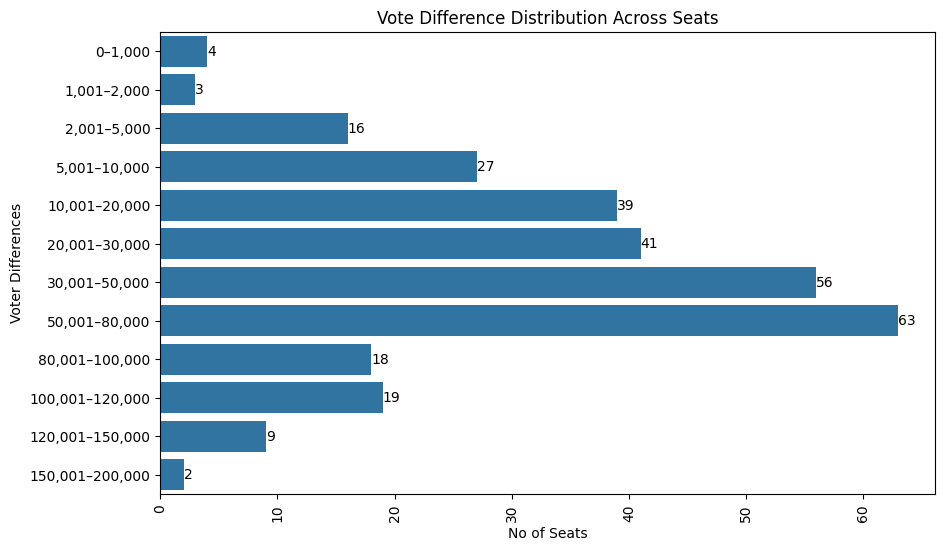

In [37]:
interval_counts4.columns = ['intervals', 'count']
# Plotting the intervals
plt.figure(figsize=(10, 6))

ax=sns.barplot(x='count', y='intervals', data=interval_counts4, orient='h')
plt.title('Vote Difference Distribution Across Seats')
plt.xlabel('No of Seats')
plt.ylabel('Voter Differences')
for index, value in enumerate(interval_counts4['count']):
    ax.text(value, index, str(value), color='black', va='center')
plt.xticks(rotation=90)

plt.show()

### Top 10 Closest Seats (Smallest Vote Difference)

This section identifies the **10 constituencies with the smallest vote difference (closest contests)**.

These seats represent the **most competitive elections**.

---

In [38]:
cols = ["seat_name", "winner_name", "winner_symbol","winner_vote","runnerup_name","runnerup_symbol","runnerup_vote","vote_diff"]

bottom_seat_10 = (
    df_seat_joined_winner_runnerup
      .nsmallest(10, "vote_diff")[cols]
)

display(bottom_seat_10)

,seat_name,winner_name,winner_symbol,winner_vote,runnerup_name,runnerup_symbol,runnerup_vote,vote_diff
279,সিরাজগঞ্জ-৪,"এম, আকবর আলী",ধানের শীষ,160458,মোঃ রফিকুল ইসলাম খান,দাঁড়িপাল্লা,159693,765
205,ব্রাক্ষণবাড়িয়া-৫,মোঃ আবদুল মান্নান,ধানের শীষ,84761,কাজী নাজমুল হোসেন,ফুটবল,83995,766
254,রাজশাহী-১,মোঃ মুজিবুর রহমান,দাঁড়িপাল্লা,169784,মোঃ শরীফ উদ্দীন,ধানের শীষ,169010,774
213,মাদারিপুর-১,নাদিরা আক্তার,ধানের শীষ,64291,সাইদ উদ্দিন আহমাদ হানজালা,রিক্সা,63511,780
99,ঢাকা-১১,মোঃ নাহিদ ইসলাম,শাপলা কলি,92038,"এম, এ, কাইয়ুম",ধানের শীষ,90969,1069
111,ঢাকা-৪,সৈয়দ জয়নুল আবেদীন,দাঁড়িপাল্লা,75683,তানভীর আহমেদ,ধানের শীষ,73762,1921
250,রংপুর-৬,মোঃ নুরুল আমীন,দাঁড়িপাল্লা,118890,মোঃ সাইফুল ইসলাম,ধানের শীষ,116919,1971
168,পাবনা-৩,মুহাম্মাদ আলী আছগার,দাঁড়িপাল্লা,145837,মোঃ হাসান জাফির তুহিন,ধানের শীষ,143540,2297
104,ঢাকা-১৬,মোঃ আব্দুল বাতেন,দাঁড়িপাল্লা,87027,মোঃ আমিনুল হক,ধানের শীষ,84632,2395
151,নেত্রকোণা-৫,মাছুম মোস্তফা,দাঁড়িপাল্লা,81252,মোঃ আবু তাহের তালুকদার,ধানের শীষ,78679,2573


### Top 10 Seats by Vote Difference (Largest Victory Margin)

This section identifies the **10 constituencies with the largest vote difference (highest victory margin)**.

These seats represent the most decisive wins.

---

In [39]:
cols = ["seat_name", "winner_name", "winner_symbol","winner_vote","runnerup_name","runnerup_symbol","runnerup_vote","vote_diff"]

top_seat_10 = (
    df_seat_joined_winner_runnerup
      .nlargest(10, "vote_diff")[cols]
)

display(top_seat_10)

,seat_name,winner_name,winner_symbol,winner_vote,runnerup_name,runnerup_symbol,runnerup_vote,vote_diff
253,রাজবাড়ী-২,মোঃ হারুন-অর-রশিদ,ধানের শীষ,234848,জামিল হিজাযী,শাপলা কলি,65293,169555
251,রাঙ্গামাটি,দীপেন দেওয়ান,ধানের শীষ,199855,পহেল চাকমা,ফুটবল,30996,168859
273,সাতক্ষীরা-২,মুহাম্মাদ আব্দুল খালেক,দাঁড়িপাল্লা,263503,মোঃ আব্দুর রউফ,ধানের শীষ,115257,148246
203,ব্রাক্ষণবাড়িয়া-৩,মোঃ খালেদ হোসেন মাহবুব,ধানের শীষ,207454,আতাউল্লাহ,শাপলা কলি,59567,147887
187,বগুড়া-৭,মোরশেদ মিলটন,ধানের শীষ,262501,মোঃ গোলাম রব্বানী,দাঁড়িপাল্লা,115184,147317
9,কিশোরগঞ্জ-৬,মোঃ শরীফুল আলম,ধানের শীষ,185795,আতাউল্লাহ আমীন,রিক্সা,42980,142815
167,পাবনা-২,"এ, কে, এম, সেলিম রেজা হাবিব",ধানের শীষ,213840,মোঃ হেসাব উদ্দিন,দাঁড়িপাল্লা,75693,138147
87,টাংগাইল-২,মোঃ আবদুস সালাম পিন্টু,ধানের শীষ,195590,মোঃ হুমায়ুন কবীর,দাঁড়িপাল্লা,59873,135717
75,জামালপুর-৩,মোঃ মোস্তাফিজুর রহমান বাবুল,ধানের শীষ,206214,মোঃ মুজিবুর রহমান আজাদী,দাঁড়িপাল্লা,79607,126607
19,কুমিল্লা-৮,জাকারিয়া তাহের,ধানের শীষ,167431,মোঃ শফিকুল আলম হেলাল,দাঁড়িপাল্লা,41345,126086


In [40]:
display(candidates_df)
display(pooling_centeres_df)


,seat_id,center_no,candidate_name,symbol,candidate_vote
0,1,163,আব্দুল্লাহ আল ফারুখ,দাঁড়িপাল্লা,303
1,1,163,মোঃ ছরওয়ার আলম কুতুবী,হাতপাখা,23
2,1,163,সালাহউদ্দিন আহমদ,ধানের শীষ,1414
3,1,145,আব্দুল্লাহ আল ফারুখ,দাঁড়িপাল্লা,670
4,1,145,মোঃ ছরওয়ার আলম কুতুবী,হাতপাখা,10
...,...,...,...,...,...
289903,297,150,মোঃ মিজানুর রহমান চৌধুরী,ঘোড়া,0
289904,297,150,মোঃ মুজিবুর রহমান,মই,0
289905,297,150,মোঃ রাশেদুল ইসলাম খোকন,ছড়ি,0
289906,297,150,শাহ মোঃ আল আমিন,হারিকেন,1


,seat_id,center_no,center_name,legal_vote,cancel_vote,Absent_vote,total_vote,cast_vote
0,1,163,"কোরআনিয়া দারুল উলুম মাদ্রাসাগ্রাম:পেকুয়রচর, ডা...",1740,34,1368,3142,1774
1,1,145,ফাঁসিয়াখালী সরকারী প্রাথমিক বিদ্যালয়গ্রাম: সবজ...,1703,19,677,2399,1722
2,1,164,করিয়ারদিয়া সরকারী প্রাথমিক বিদ্যালয়গ্রামঃ করিয়...,919,19,494,1432,938
3,1,148,"টৈটং হাই স্কুলগ্রাম:+ডাক+ইউনিয়ন: টৈটং, উপজেলা:...",2032,46,823,2901,2078
4,1,32,ঢেমুশিয়া জিন্নত আলী চৌং উচ্চ বিদ্যালয়জমিদার পা...,2078,38,1156,3272,2116
...,...,...,...,...,...,...,...,...
42379,297,146,বড়ধলিয়া জগদীশপুর প্রগতি সরকারী প্রাথমিক বিদ্যা...,2049,51,1570,3670,2100
42380,297,147,"বানেশ্বর সরকারী প্রাথমিক বিদ্যালয়, সাং- বানেশ্...",948,4,891,1843,952
42381,297,148,বানেশ্বর উচ্চ বিদ্যালয় সাং- বানেশ্বরগ্রামঃ বান...,1109,7,827,1943,1116
42382,297,149,"ধনকুড়া সরকারী প্রাথমিক বিদ্যালয়, সাং- ধনকুড়াগ্...",1822,57,1422,3301,1879


## Candidate Forfeit Analysis
---

### 1) Candidate-Level Vote Summarization


In [42]:
df_candidate_vote_summ=  candidates_df.groupby(['seat_id','candidate_name','symbol'])[['candidate_vote']].sum().reset_index()
df_seat_wise_summ=  pooling_centeres_df.groupby(['seat_id'])[['cast_vote','legal_vote']].sum().reset_index()



display(df_seat_wise_summ)

,seat_id,cast_vote,legal_vote
0,1,355537,349540
1,2,229624,224170
2,3,348939,343486
3,4,252646,247782
4,5,270777,262385
...,...,...,...
292,293,260051,254643
293,294,212186,206663
294,295,199269,194023
295,296,212269,206953


### 1) Join Seat-Level Vote Summary with Master Seat Data



In [45]:
df_seat_joined_seat_wise_summ= pd.merge(
    seats_df,
    df_seat_wise_summ,
    on=["seat_id"],
    how="left"
)

  
df_final_joined_candidate_vote_summ =  pd.merge(
    df_seat_joined_seat_wise_summ,
    df_candidate_vote_summ,
    on=["seat_id"],
    how="left"
)


df_final_joined_candidate_vote_summ['Isforfeited'] = np.where((df_final_joined_candidate_vote_summ['candidate_vote']/df_final_joined_candidate_vote_summ['legal_vote'])*100 < 12.5, 'YES', 'NO')



display(df_final_joined_candidate_vote_summ)

,zilla_name,seat_id,seat_name,cast_vote,legal_vote,candidate_name,symbol,candidate_vote,Isforfeited
0,কক্সবাজার,1,কক্সবাজার-১,355537,349540,আব্দুল্লাহ আল ফারুখ,দাঁড়িপাল্লা,125311,NO
1,কক্সবাজার,1,কক্সবাজার-১,355537,349540,মোঃ ছরওয়ার আলম কুতুবী,হাতপাখা,4471,YES
2,কক্সবাজার,1,কক্সবাজার-১,355537,349540,সালাহউদ্দিন আহমদ,ধানের শীষ,219758,NO
3,কক্সবাজার,2,কক্সবাজার-২,229624,224170,আলমগীর মুহাম্মদ মাহফুজ উল্লাহ ফরিদ,ধানের শীষ,124660,NO
4,কক্সবাজার,2,কক্সবাজার-২,229624,224170,"এ, এইচ, এম হামিদুর রহমান আযাদ",দাঁড়িপাল্লা,89817,NO
...,...,...,...,...,...,...,...,...,...
2006,হবিগঞ্জ,297,হবিগঞ্জ-৪,306610,299070,মোঃ মিজানুর রহমান চৌধুরী,ঘোড়া,646,YES
2007,হবিগঞ্জ,297,হবিগঞ্জ-৪,306610,299070,মোঃ মুজিবুর রহমান,মই,324,YES
2008,হবিগঞ্জ,297,হবিগঞ্জ-৪,306610,299070,মোঃ রাশেদুল ইসলাম খোকন,ছড়ি,479,YES
2009,হবিগঞ্জ,297,হবিগঞ্জ-৪,306610,299070,শাহ মোঃ আল আমিন,হারিকেন,531,YES


### Forfeited vs Non-Forfeited Candidates Distribution

This section visualizes the distribution of candidates based on their **forfeiture status** using a pie chart.

---

## 1) Count Forfeiture Categories

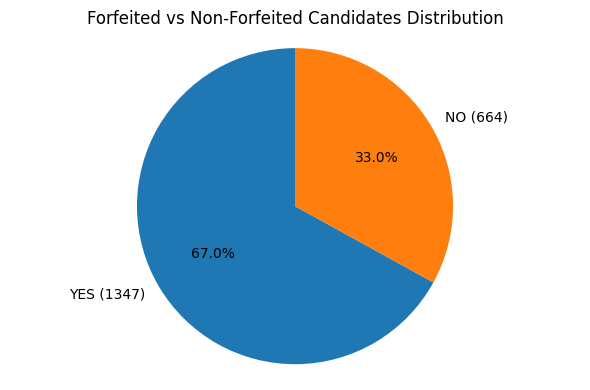

In [ ]:
grouped_counts = (
    df_final_joined_candidate_vote_summ['Isforfeited']
    .value_counts()
    .reset_index()
)
grouped_counts.columns = ['category', 'count']

# Plotting the pie chart
plt.figure(figsize=(6, 4))

labels = [
    f'{row["category"]} ({row["count"]})'
    for _, row in grouped_counts.iterrows()
]

plt.pie(
    grouped_counts['count'],
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Forfeited vs Non-Forfeited Candidates Distribution')
 

plt.axis('equal')  # Keeps the pie circular
plt.tight_layout()
plt.show()

Madaripur-1 ,Narayanganj-4